In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import source.lpa_master as LPA
from natsort import natsorted
from source import helpers
import seaborn as sns
import pandas as pd
import numpy as np
import regex as re
import json
import os

> Dir `data_imports` already exists.
> Dir `data_processed` already exists.
> Dir `lpa_input` already exists.
> Dir `lpa_results` already exists.


In [2]:
class lpa_prep():
    def __init__(self,
                 metric : str = 'substitution_survival'):
        """
        metric : str -> Metric on which the analysis will be performed.
        substitution_survival - analyze the selection patterns (through non-syn mutations survival) across the heavy variable regions of the immune reportiore.
        trimers_usage - analyze the trimers (k-mers) usage of across the heavy variable regions of the immune reportiore.
        """
        
        if metric not in ["substitution_survival", "trimers_usage"]:
            raise Exception("Invalid metric input, valid inputs are: 'substitution_survival', 'trimers_usage'.")

        # Required tables for the selected analysis
        req_tables = {"substitution_survival":["clones", "clone_stats", "sample_metadata"],
                      "trimers_usage":["sequences","sequence_collapse", "sample_metadata"]}
        
        # Defining varibles to be used across the analysis
        self.config = helpers.read_json() #config information, used for sql connection
        self.metric = metric # metric on which the data will be analyzed
        self.req_tables = req_tables[metric] # required sql tables
        self.analysis_mame = "-".join([self.config["sql"]["database"], self.metric]) # analysis name 

        # required folders per step
        self.paths = {"data_imports": os.path.join("data_imports", self.analysis_mame),
                      "data_processed": os.path.join("data_processed", self.analysis_mame),
                      "lpa_input": os.path.join("lpa_input", self.analysis_mame),
                      "lpa_results": os.path.join("lpa_results", self.analysis_mame)}
        
        helpers.create_folders([os.path.join(i, self.analysis_mame) for i in self.paths])

        self.required_files = {"substitution_survival":"mut_df.csv",
                               "trimers_usage":"cleaned_seqs.csv"}
        self.req_processed = self.required_files[self.metric]

    # Class methods which imports raw tables from the sql server
    def import_tables(self):
        sql_database = self.config["sql"]["database"]
        data_path = self.paths["data_imports"]
        imported_tabeles = []
        
        if os.path.exists(os.path.join(self.paths["data_processed"], self.req_processed)):
            print(f"> `{self.req_processed}` exists, no need to import file. use pruge_file() if needed.")

        else:
            try:
                sql_connecntion = helpers.mysql_qry()
                print(f"> Connected to the MySQL server ({sql_database}).")

            except:
                print(f"> Failed to connect to the MySQL server ({sql_database}).")
            
            for i in self.req_tables:
                print(f"{i}.csv:")
                i_path = os.path.join(data_path, i+".csv")

                if os.path.exists(i_path):
                    print(f"> raw table `{i}` already exists at {i_path}. continuing.")

                else:
                    print(f"> importing table `{i}` to {i_path}.")

                    temp_qry = f"""
                                SELECT * FROM {sql_database}.{i};
                                """
                
                    # Incase of invalid input error
                    try:
                        temp_df = sql_connecntion.run_qry(temp_qry)
                        temp_df.to_csv(i_path)
                        imported_tabeles.append(i)

                    except:
                        print(f"> Invalid database or table name. (db={self.config["sql"]["database"]}, table={i})")
                        
            sql_connecntion.close_conn()

            files_actual = np.sort(os.listdir(data_path))
            files_expected = np.sort([i+".csv" for i in self.req_tables])
            print(f"imported tabled:{files_actual} from required talbed: {files_expected} ({len(files_actual)}/{len(files_expected)})")

    def process_tables(self,
                       metadata_columns : str,
                       metadata_rename : str = None,
                       aa_range : tuple = (1,104),
                       unique_seq_filt : int = 1,):
        """
        metadata_columns : str -> name of the metadata columns which are required from the metadata file.
        metadata_rename : str -> new names for the metadata columns. If None -> same names.
        aa_range : tuple / list -> range of the amino acids position which will be included in the analysis.
        unique_seq_filt : int -> Threshold (>) of required unique sequences per clone.
        * only functional clones
        * Include only non-synonymous mutations. 
        * Creating orginized metadata dataframe with the information provided by the config.json file.
        * Saving the metadata_df into folder.
        * If the dataframe already exists, load it without processing.
        """
        if os.path.exists(os.path.join(self.paths["data_processed"], self.req_processed)):
            print(f"> `{self.req_processed}` exists, no need to import file. use pruge_file() if needed.")

        else:
            if metadata_rename is None:
                metadata_rename = metadata_columns

            # > PREPROCESSING FOR SUBSTITUTION SURVIVAL < #
            if self.metric == "substitution_survival":            
                """
                aa_range : tuple / list -> range of the amino acids position which will be included in the analysis.
                unique_seq_filt : int -> Threshold (>) of required unique sequences per clone.
                * only functional clones
                * Include only non-synonymous mutations. 
                * Creating orginized metadata dataframe with the information provided by the config.json file.
                * Saving the metadata_df into folder.
                * If the dataframe already exists, load it without processing.
                """

                path_processed_dir = self.paths["data_processed"]
                path_metdadata_df = os.path.join(path_processed_dir, "sample_metadata_df.csv")

                if os.path.exists(path_metdadata_df):
                    print("> sample_metadata_df.csv already created, continuing...")
                    metadata_df = pd.read_csv(path_metdadata_df, index_col=0)
                                                                                            
                else:
                    print("> Creating sample_metadata_df.csv.")
                
                    metadata_keys_og = metadata_columns.split(",")
                    metadata_keys_new =  metadata_rename.split(",")
                    meta_dict = dict(zip(metadata_keys_og, metadata_keys_new))

                    metadata_df = pd.read_csv(os.path.join(self.paths["data_imports"], "sample_metadata.csv"), index_col=0)
                    metadata_og = metadata_df[metadata_df["key"].isin(metadata_keys_og)]
                    metadata_og = metadata_og.replace({"key":meta_dict})

                    sample_ids = np.sort(metadata_og["sample_id"].unique())
                    metadata_df = pd.DataFrame({"sample_id":sample_ids})
                    metadata_df[metadata_keys_new] = np.nan

                    for i in sample_ids:
                        temp_sid = i
                        for j in metadata_keys_new:
                            cond_sid = (metadata_og["sample_id"] == i)
                            cond_key = (metadata_og["key"] == j)
                            metadata_df.loc[metadata_df["sample_id"]==i,j] = metadata_og.loc[(metadata_og["sample_id"]==i)&(metadata_og["key"]==j),"value"].values
                    metadata_df.to_csv(path_metdadata_df)
                    print("> Done.")

                # Creation of filtred metadata table
                """
                * Creating custom function to pull metadata from metadata_df
                * sample_id validation
                """
                def assign_metadata(sample_id, meta_df):
                    meta_list = meta_df.columns[1:]
                    meta_sample = meta_df.loc[meta_df["sample_id"]==sample_id, meta_list].values.flatten()
                    return meta_sample
                
                clone_stats = pd.read_csv(os.path.join(self.paths["data_imports"], "clone_stats.csv"), index_col=0)
                metalist_sids = np.sort(metadata_df.sample_id.unique())
                clones_sids = np.sort(clone_stats.dropna().sample_id.unique()).astype("int")

                values_missing = np.setdiff1d(clones_sids, metalist_sids)
                values_common = np.intersect1d(metalist_sids, clones_sids)

                if len(values_missing) > 0:
                    print("> missing sample_id from metadata file:",values_missing)
                    clone_stats = clone_stats[clone_stats["sample_id"].isin(values_common)]
                    raise TypeError("verify metadata sample_id values") 
            
                # Merging clones and clones status > adding the relevent metadata to the dataframe
                """
                * loading clones_merged if exists, if not creating and saving
                * custom function that extract mutations infromation from the "mutation" json in each row
                * Adding the germline infromation to the clone_stats df
                * Dropping null sample_id rows (cannot assign metadata for those rows)
                * converting "sample_id" values to int instead of floats
                * assiging the metadata into the merged table (applying assign_metadata)
                * renaming id_x to id after merging (left had "id" colum while right had "id"=="clone_id")
                * reseting the index
                """
                
                path_clones_merged = os.path.join(self.paths["data_processed"], "clones_merged.csv")

                if os.path.exists(path_clones_merged):
                    clones_merged = pd.read_csv(path_clones_merged)
                    print("> clones_merged dataframe exists, loading and continuing....")

                else: 
                    clones = pd.read_csv(os.path.join(self.paths["data_imports"], "clones.csv"))
                    clones_merged = clone_stats.merge(right=clones[["id","germline"]],
                                                        how="left",
                                                        left_on="clone_id",
                                                        right_on="id")    
                    
                    clones_merged = clones_merged[clones_merged["sample_id"].notnull()]        
                    clones_merged[list(metadata_df.columns)[1:]] = list(clones_merged["sample_id"].apply(assign_metadata, args=(metadata_df,)))
                    clones_merged.rename({"id_x":"id"},axis="columns",inplace=True)
                    clones_merged.reset_index(drop=True, inplace=True)
                    clones_merged.to_csv(path_clones_merged)
                    print("> clones_merged dataframe created and saved, continuing....")

                # Creating the mutation dataframe
                """
                * Creating df with the relevent mutations infromation for each clone (mut_df)
                * Cleaning the mut_df and adding relevent data
                * Saving the mut_df
                """

                path_mut_df = os.path.join(self.paths["data_processed"], "mut_df.csv")

                if os.path.exists(path_mut_df):
                    mut_df = pd.read_csv(path_mut_df,index_col=0)
                    print("> mut_df dataframe exists, loading and continuing....")

                else: 
                    def mut_regall(string):
                        pattern = r"'pos': (?P<position>\d+), 'from_nt': '(?P<from_nt>[\w]+)', 'from_aa': '(?P<from_aa>[\w\*]+)', 'to_nt': '(?P<to_nt>['\w\*]+)', 'to_aas': \[(?P<to_aas>['\w,\s\*]+)], 'unique': (?P<unique>\d+), 'total': (?P<total>\d+), 'intermediate_aa': '(?P<intermediate_aa>[\w\d\*])'"
                    
                        tjson = json.loads(string)
                        
                        if "ALL" in str(tjson["regions"].keys()):
                            all_value = str(tjson["regions"]["ALL"])
                            find = re.findall(pattern,all_value)
                            return find
                        
                        else:
                            else_value = str(tjson["regions"])
                            return else_value
                            
                    clones_merged["regions_all"] = clones_merged["mutations"].apply(mut_regall)
                    clones_raval = clones_merged.copy()
                    ra_val = []
                    
                    for i in range(0,len(clones_raval)):
                        length = len(clones_raval.loc[i,"regions_all"]) # length of the list, number of mutations is the colum
                        value = clones_raval.loc[i,"regions_all"] # the value mutations themselves list of lists/ list / np.nan
                        id_value = clones_raval.loc[i,"id"] # id value of the row
                        clone_id = clones_raval.loc[i,"clone_id"] # clone_id value of the row
                        subject_id = clones_raval.loc[i,"subject_id"]# subject_id value of the row
                        sample_id = clones_raval.loc[i,"sample_id"] # sample_id value of the row
                        funct = clones_raval.loc[i,"functional"] # functional value of the clone
                        total_cnt = clones_raval.loc[i,"total_cnt"] # target of the antibody
                        unique_cnt = clones_raval.loc[i,"unique_cnt"] # unique sequence is clone
                        germline = clones_raval.loc[i,"germline"] #germline sequence
                        top_seq = clones_raval.loc[i,"top_copy_seq_sequence"] #top copy of sequence
                        metadata = clones_raval.loc[i,metadata_df.columns[1:]].values.flatten().tolist() #metadata list value
                        ins_val = [id_value, clone_id, subject_id, sample_id, funct, total_cnt,unique_cnt, germline, top_seq] + metadata
                        
                        # if single row of mutation
                        if length == 1:
                            to_aas = value[0][4].replace(" ","").replace("''","").split(",")
                            
                            if (len(to_aas) == 1):
                                temp_list = list(value[0])
                                ra_val.append(ins_val + temp_list) 
                                
                            else:
                                for i in range(0,len(to_aas)):
                                    temp_list = list(value[0])
                                    temp_list[4] = to_aas[i]
                                    ra_val.append(ins_val + temp_list)
                        
                        # if multiple rows of mutations
                        if length > 1:
                            for j in range(0,length):
                                    sub_value = list(value[j]) #each row
                                    temp_list = sub_value
                                    
                                    # making sure that the length of the list is correct, in some rows there is missing values
                                    if len(sub_value) == 8:
                                        to_aas = sub_value[4].replace(" ","").replace("'","").split(",")
                                        
                                        if len(to_aas) == 1:
                                            ra_val.append(ins_val + temp_list)
                                        elif len(to_aas) > 1:
                                            for aa in set(to_aas): # set() removes duplicate values
                                                temp_list[4] = aa
                                                ra_val.append(ins_val + temp_list)
                                                        
                        elif length == 0:
                            ra_val.append(ins_val + np.full(shape=len(value), fill_value=np.nan).tolist())
                    
                    mut_df_cols = ["id", "clone_id", "subject_id", "sample_id", "functional", "total_cnt","unique_cnt", "germline", "top_seq"]
                    mut_info_cols = ["pos","from_nt","from_aa","to_nt","to_aas","unique","total","intermidiate_aa"]
                    
                    mut_df = pd.DataFrame(data=ra_val, columns = mut_df_cols + metadata_df.columns[1:].tolist() + mut_info_cols)
                    mut_df["to_aas"] = mut_df["to_aas"].str.replace("'","") #cleaning to_aas string
                    mut_df.replace({"to_aas":{"None":np.nan}}, inplace=True) #turining none values to np.nan
                    mut_df.dropna(axis=0,subset=["pos","to_aas"], ignore_index=True, inplace=True) #dropping null rows of "pos" and "to_aas"
                    
                    mut_df.insert(6,"pos_aa",np.nan) #inserting amino acid position column
                    mut_df.insert(6,"pos_nt",np.nan) #inserting nucleotide position column
                    mut_df.loc[:,"pos_nt"] = mut_df.loc[:,"pos"].apply(int)+1 #filling the pos_nt column
                    mut_df.loc[:,"pos_aa"] = ((mut_df.loc[:,"pos_nt"])/3).apply(helpers.round_up) #fillint the pos_aa column 
                    mut_df.astype({"pos_nt":"int","pos_aa":"int"})
                    mut_df.drop(axis=1,columns="pos",inplace=True) #dropping the og column (it was -1 in position...)
                    mut_df["syn"] = (mut_df["from_aa"] == mut_df["to_aas"]).apply(int) #creating syn column

                    mut_df.to_csv(path_mut_df)
                    print("> mut_df dataframe created and saved, continuing....")
                    
                    print("> Successfully created mutation dataframe (mut_df.csv)")

                    # Filtring mutataion dataframe
                    filt_pos_aa = (mut_df["pos_aa"].between(aa_range[0], aa_range[1], inclusive='both')) # from aa positions 1->104
                    filt_unique_cnt = (mut_df["unique_cnt"] > unique_seq_filt) # only clones with more than 1 unique sequence
                    filt_functional = (mut_df["functional"] == 1) # only functional clones
                    filt_syn = (mut_df["syn"] == 0) # only non-syn mutations (substitutions)

                    self.filt_mut_df = mut_df[filt_pos_aa & filt_functional &  filt_syn & filt_unique_cnt]
                    self.filt_mut_df.to_csv(path_mut_df)
                    print("> mut_df dataframe created and saved, continuing....")

            # > DATA PROCESSING FOR TRIMERS USAGE < #
            elif self.metric == "trimers_usage":
                # Defining folders paths
                raw_folder_path = self.paths["data_imports"]
                processed_folder_path = self.paths["data_processed"]
                cleaned_seqs_path = os.path.join(processed_folder_path, "cleaned_seqs.csv")
                
                # metadata from required from metadata table
                metadata_list = metadata_columns.split(",")
                relevent_cols = ["seq_id", "ai", "sample_id", "subject_id", "clone_id", "functional", "copy_number",  "cdr3_aa", "sequence", "germline"]
                
                # Defining raw input file paths: "sequences","sequence_collapse", "sample_metadata"
                seqs_loc = os.path.join(raw_folder_path, "sequences.csv")
                seq_collapsed_loc = os.path.join(raw_folder_path, "sequence_collapse.csv")
                metadata_loc = os.path.join(raw_folder_path, "sample_metadata.csv")

                # If the processed sequcnes csv already exists in the defualt location it will be imported.
                if os.path.exists(cleaned_seqs_path):
                    print("> Found cleaned_seqs.csv in the procesed tables folder.")

                # Creating the processed sequcnes file.
                else:
                    # Importing the sequences csv
                    # Filtring out: non-functional seqs, non-sample specific and  non-clone specific
                    seqs = pd.read_csv(seqs_loc, index_col=0)[relevent_cols]
                    self.seqs_col = pd.read_csv(seq_collapsed_loc, index_col=0)
                    
                    # Importing the metadata csv and orginizing the dataframe for the relevent information.
                    metadata = pd.read_csv(metadata_loc, index_col=0)
                    metadata_df = metadata.groupby(["sample_id","key"]).describe().reset_index()[[("sample_id",""), ("key",""), ("value","top")]].droplevel(level=1,axis=1)
                    metadata_df = metadata_df[metadata_df.key.isin(metadata_list)]
                    
                    # Creating metadata dataframe in order to join it's values to the sequences dataframe
                    data_mtdata = []
                    for j in metadata_df.key.unique():
                        data_mtdata.append(metadata_df[metadata_df.key==j].drop("key",axis=1).rename({"value":j},axis=1).reset_index(drop=True))
                    
                    result_metadata = pd.concat(data_mtdata, axis=1).T.drop_duplicates().T[["sample_id"] + metadata_list]

                    # Renaming the metadata columns names according to the rename_metadata & new_metadata_names arguments
                    if metadata_rename is not None:
                        rename_dict = {i:j for i,j in zip(metadata_list, metadata_rename.split(","))}
                        result_metadata.rename(rename_dict, axis=1, inplace=True)
                        metadata_list = metadata_rename.split(",")
                    
                
                    # Placing the metadata values into the sequcnes dataframe
                    result_dict = {i[1]:[i[2],i[3]] for i in result_metadata.itertuples()}
                    
                    seqs[metadata_list] = np.nan
                    for i in seqs.sample_id.unique():
                        if i in result_dict.keys():
                            seqs.loc[seqs.sample_id == i, metadata_list] = result_dict[i]

                    #seqs[metadata_list] = list(seqs.sample_id.apply(lambda X : result_dict[X]).values)
                    self.cleaned_seqs = seqs.copy()

                    # Creating unique sequences only dataframe
                    unique_seq_list = self.seqs_col.loc[(self.seqs_col.seq_ai.isin(self.cleaned_seqs.ai.values)) & (self.seqs_col.instances_in_subject > 0), "collapse_to_subject_seq_id"].values
                    self.cleaned_seqs = self.cleaned_seqs[self.cleaned_seqs.seq_id.isin(unique_seq_list)]

                    # Filtring out rows woth NT sequence that dosent divide by 3 and getting report df
                    self.dropped_3dv = self.cleaned_seqs[(self.cleaned_seqs.germline.str.count("-")%3 != 0) | (self.cleaned_seqs.sequence.str.count("-")%3 != 0)]
                    self.cleaned_seqs = self.cleaned_seqs[(self.cleaned_seqs.germline.str.count("-")%3 == 0) & (self.cleaned_seqs.sequence.str.count("-")%3 == 0)]

                    # Saving the the cleaned sequences data into the defualt location
                    self.cleaned_seqs.to_csv(cleaned_seqs_path)
                    ("> 'cleaned_seqs.csv' saved to processed_data folder.")


    def create_documents(self,
                         document,
                         substitution_element : str = None,
                         trimer_source : str = None,
                         metric_dataframe : pd.DataFrame = None,
                         overwrite : bool = False):
        
        """
        document : str -> string list of the columed to be used as document label, such as exaple: "col1,col2,col3".
        substitution_element : str -> on what element the substitution analysis will be performed, defualt is `pos_aa`.
        trimer_source : str -> on which type of analysis the trimers analysis usage will be performed: `all_seq` or `top_seq` or "germline" (`source_dict` var).
                                a. 'germline' - will create trimmers based on the germline sequences of the unique clones.
                                b. 'top_seq' - will create trimmers based on the germline sequences of the top clone sequence (seq with 
                                    the highers number of reads whitin clone).
                                c. 'all_seqs' - will create trimmers based on all of the sequences whitin a clone
        metric_dataframe : pd.DataFrame -> option to use modified metric dataframe, by defualt loads from `data_processed` folder.
        overwrite : bool -> overwrite current lpa input file.
        """
        
        path = self.paths["lpa_input"]
        file = os.path.join(path, "lpa_documents.csv")

        if (overwrite is False) & os.path.exists(file):
            print("> `lpa_input.csv` exsits and overwrite = False. Wont create new file.")
        
        else:
            path_metric_df = os.path.join(self.paths["data_processed"], self.req_processed)
            if metric_dataframe is None:
                metric_df = pd.read_csv(path_metric_df, index_col=0)
                print("> Loaded processed metric dataframe.")
            
            # Loading metric dataframe
            else:
                try:
                    metric_df = metric_dataframe
                    print("> Loaded pd.DataFrame metric dataframe.")
                except:
                    metric_df = pd.read_csv(path_metric_df , index_col=0)
                    print("> Loaded processed metric dataframe.")
                    
            if os.path.exists(os.path.join(self.paths["data_processed"], self.req_processed)): 
                # > LPA DOCUMENT MAKER FOR SUBSTITUTION SURVIVAL < #           
                if self.metric == "substitution_survival":
                    substitution_element = "pos_aa" # 'makeshift' var
                    element = substitution_element
                    metric_df["element"] = metric_df[element].astype("int")

                    document = document.split(",")
                    for i in document:
                        if i == document[0]:
                            metric_df["document"] = metric_df[i]
                        
                        else:
                            metric_df["document"] += "." + metric_df[i].astype("str")
                    
                    grouped_df = metric_df.groupby(["document","element"]).size().reset_index()
                    grouped_df.columns = [i for i in grouped_df.columns[:-1]] + ["frequency_in_document"]

                    documents_df = []

                    for doc in natsorted(grouped_df.document.unique()):
                        og_doc = grouped_df[grouped_df["document"] == doc]
                        temp_df = pd.DataFrame({"document":doc, "element":range(1, 105), "frequency_in_document":0})
                        temp_df.loc[temp_df.element.isin(og_doc.element),"frequency_in_document"] = og_doc["frequency_in_document"].values

                        documents_df.append(temp_df)

                    output_df = pd.concat(documents_df, axis=0)
                    output_df.to_csv(file)
                    print("> Created lpa input succseffuly")

                # > LPA DOCUMENT MAKER FOR TRIMERS USAGE < #
                elif self.metric == "trimers_usage":
                    # Creating labels for each sequence based on the subdatasets_list argument.
                    cleaned_seqs_path = os.path.join(self.paths["data_processed"], "cleaned_seqs.csv")
                    cleaned_seqs = pd.read_csv(cleaned_seqs_path, index_col=0)
                    cleaned_seqs = cleaned_seqs[(cleaned_seqs.ab_target.isnull() == False)]
                    source = trimer_source
                    subdatasets_list = document.split(",")
                    labels = None

                    # Generating label column
                    for col in subdatasets_list:
                        temp_val = cleaned_seqs[col].astype("str").str.replace(" ","")
                        if labels is None:
                            labels = temp_val
                        else:
                            labels += "." + temp_val

                    # assiging the labels to the labels column
                    cleaned_seqs["label"] = labels
                
                    source_dict = {"germline":"germline", "top_seq":"sequence", "all_seq":"sequence"}
                    if source in ["germline", "top_seq"]:
                        idx = cleaned_seqs.groupby('clone_id')['copy_number'].idxmax()
                        input_df = cleaned_seqs.loc[idx, ["label", "clone_id", "cdr3_aa"] + [source_dict[source]]]
                    
                    elif source == "all_seq":
                        input_df = cleaned_seqs[["label","clone_id","cdr3_aa","sequence"]]

                    else:
                        raise Exception("Invalid source argument input string") 
                
                    output_dfs = []
                    unique_clones = []
                    n_ulbl = len(cleaned_seqs.label.unique())
                    print(f"> Itirating over sub-datasets (n={n_ulbl})")
                    for ulbl in cleaned_seqs.label.unique():
                        temp_output = input_df[input_df.label == ulbl]
                        unique_clones.append([ulbl, temp_output.shape[0]]) # save the unique number of sequences per dataset
                        temp_output = (temp_output.cdr3_aa + "." + temp_output[source_dict[source]]).apply(helpers.nt_transalte_104)
                        temp_df = None

                        print(f"Concatenating {ulbl} sub-dataset analysis results") #[{}/{n_ulbl}]")
                        for nij in temp_output:
                            if nij is None:
                                temp_df = nij
                            else:
                                temp_df = pd.concat([temp_df, nij], axis=0)
                        
                        temp_df["label"] = ulbl
                        output_dfs.append(temp_df)

                    self.trimers = pd.concat(output_dfs).groupby(["label","first_aa","region","trimer"]).count().reset_index()
                    self.trimers = self.trimers[self.trimers.region.isin(['cdr1', 'fw2', 'cdr2', 'fw3'])]
                    self.trimers.to_csv(os.path.join(self.paths["data_processed"], "trimers_df.csv"))
                    
                    self.lpa_input = self.trimers[["label","trimer","ncount"]]
                    self.lpa_input.columns = ["document", "element", "frequency_in_document"]
                    self.lpa_input = self.lpa_input.groupby(["document","element"]).sum().reset_index()

                    self.lpa_input.to_csv(file) #saves trimers output
                    pd.DataFrame(unique_clones, columns=["label", "unique_seqs"]).to_csv(file.split(".")[0] + "-unqseqs.csv") #saves unique clones of datasets
                    print("> Trimers and unique clones data saved to 'trimers_output' folder.")

In [ ]:
def name_cmap(cmap_name:str) -> list:
    cmap_hex = []
    for color in plt.get_cmap(cmap_name).colors:
        hex_color = '#{:02x}{:02x}{:02x}'.format(int(color[0]*255), int(color[1]*255), int(color[2]*255))
        cmap_hex.append(hex_color)
    return cmap_hex

class lpa_analysis():
    def __init__(self,
                 metric : str = 'substitution_survival',
                 min_treshold : int = 0,
                 keep_zero_freq : bool = True,
                 lpa_input = None,
                 label_dict : dict = None):
    
        """
        metric : str -> Data analysis metric. "substitution_survival" or "trimers_usage".
        lpa_input : pd.DataFrame / str -> string path or dataframe variable of lpa input csv.
        min_treshold: int -> treshold for number of trimers in documents, lower values from this treshold will be dropped.
        keep_zero_freq: -> Keeping trimers with zero occurnces, the LPA algorithm drops them automaticly.
        label_dict : dict ->
        """
        
        # Setting lpa paths
        config =  helpers.read_json()
        self.metric = metric
        self.folder_name = f"{config["sql"]["database"]}-{self.metric}"
        self.lpa_input_path = os.path.join("lpa_input", self.folder_name, "lpa_documents.csv")
        self.lpa_output_path = os.path.join("lpa_results", self.folder_name)

        # Loading lpa input file
        if isinstance(lpa_input, pd.DataFrame):
            self.lpa_input = lpa_input
        
        elif isinstance(lpa_input, str):
            try:
                self.lpa_input = pd.read_csv(lpa_input, index_col=0)
            except:
                print(f"> Invalid lpa input path: {lpa_input}")
        
        else:
           self.lpa_input = pd.read_csv(self.lpa_input_path, index_col=0)


        # Removing documents with 
        if isinstance(min_treshold, int):
            doc_max = self.lpa_input.groupby("document").max().reset_index()
            self.low_docs = doc_max[doc_max.frequency_in_document < min_treshold].document.values
            self.high_docs = doc_max[doc_max.frequency_in_document >= min_treshold].document.values

            self.lpa_input = self.lpa_input[self.lpa_input.document.isin(self.high_docs)]
            print(f"> The following document havn't met the treshold ({str(min_treshold)}):")
            print(doc_max.loc[doc_max.document.isin(self.low_docs), ["document", "frequency_in_document"]])

        if keep_zero_freq:
            unique_trimers =  np.sort(self.lpa_input.element.unique())
            unique_labels = self.lpa_input.document.unique()
            template_df = pd.DataFrame(index=unique_trimers)

            temp_dfs = []
            for label in unique_labels:
                input_df = self.lpa_input[self.lpa_input.document == label].set_index("element")["frequency_in_document"]
                conc_df = pd.concat([template_df, input_df], axis=1).fillna(0).astype("int")
                conc_df["document"] = label
                temp_dfs.append(conc_df)

            self.lpa_input = pd.concat(temp_dfs, axis=0).reset_index(drop=False, names="element")[["document", "element", "frequency_in_document"]]
        

        # Replacing zeros with null values
        self.lpa_input = self.lpa_input.replace(np.inf, np.nan).dropna(axis=0, how="all")

        # Starting to perform the LPA analysis
        # creating corpus and domain 
        corpus = LPA.Corpus(freq=self.lpa_input)
        dvr = corpus.create_dvr()

        # sorting the domain by element value
        dvr_sort = dvr.sort_values(by="element").reset_index(drop=True)

        # defining epsilon for KLDe distance calculation
        epsilon_frac = 2
        epsilon = 1 / (len(dvr) * epsilon_frac)

        # creating distances signatures for each document
        signatures = corpus.create_signatures(epsilon=epsilon, sig_length=None, distance="KLDe")
        sig_list = [i.sort_index() for i in signatures]

        self.sig_df = dvr_sort.copy()["element"].to_frame()

        # Creating dataframe of signatures
        for i in sig_list:
           self.sig_df = self.sig_df.merge(right=i.to_frame(), how="left", left_on="element", right_index=True) 
            
        self.sig_df.set_index(keys="element", drop=True, inplace=True)
        self.sig_df = self.sig_df[np.sort(self.sig_df.columns)]

        # Replacing zeros with null values
        self.x_range = self.sig_df.replace(np.inf, np.nan).dropna(axis=0, how="all").index

    # Heatmap plot: KLDe distances of each dataset from the shared domain
    def heatmap(self,
                mask_input : pd.DataFrame = None,
                save_fig : bool = True) -> plt.Figure:
        
        domain_df = self.sig_df[self.sig_df.index.isin(self.x_range)]
        fhight = domain_df.shape[1]/5
        fig, ax = plt.subplots(1,1, figsize=(20,fhight))


        if mask_input is None:
            mask_df = np.full(domain_df.shape,False)

        try:
            cond_shape = (mask_input.shape == domain_df.shape)
            if cond_shape:
                mask_df = mask_input
            else:
                mask_df = np.full(domain_df.shape,False)
        except:
            mask_df = np.full(domain_df.shape,False)
        
        sns.heatmap(data=domain_df.T,
                    cbar_kws={'label': 'KLDe Distance'},
                    cmap="turbo",
                    xticklabels=True,
                    yticklabels=True,
                    mask=mask_df.T,
                    ax=ax)
        
        cbar_ax = ax.figure.axes[-1]
        cbar_ax.tick_params(labelsize=11)
        cbar_ax.yaxis.get_label().set_fontsize(15)

        ax.tick_params(axis="both", labelsize=11)
        ax.set_xlabel("Position", fontsize=15)
        ax.set_ylabel("Repertoire", fontsize=15)

        range_all = range(1,105) #FR1, CDR1, FR2, CDR2, FR3
        range_cdr = list(range(27,39)) + list(range(56,66)) #CDR1, CDR2
        range_fr = list(range(1,27))+list(range(39,56))+list(range(66,105)) #FR1,FR2,FR3
        for xtick, xcolor in zip(ax.get_xticklabels(), ["red" if i in range_cdr else "blue" for i in domain_df.T.columns]):
            xtick.set_color(xcolor)

        if save_fig == True:
            fig.savefig(os.path.join(self.lpa_output_path,"heatmap.png"), bbox_inches='tight')

    def pca(self,
            plot : bool = True):

            df_input = self.sig_df[self.sig_df.index.isin(self.x_range)].T
            
            pca_object = PCA(n_components=0.95, random_state=0)
            pca_object.fit(df_input)
            pca_output = pca_object.transform(df_input)
            pca_evar = pca_object.explained_variance_ratio_
            self.pca_df = pd.DataFrame(data = pca_output,
                                index = df_input.index,
                                columns = [f"PC{i+1}" for i in range(0,pca_output.shape[1])])
            
            self.pca_var = pd.DataFrame({"PC":self.pca_df.columns, "Variance":pca_evar})
            
            if plot:
                plt.bar(x=self.pca_df.columns, height=pca_evar)
                plt.xlabel("PC")
                plt.ylabel("Explaned Variance")
                plt.show()
                
            return self.pca_df, self.pca_var


    def pca_scatter(self,
                    n_pcs:int = 3,
                    label_index:int = None,
                    save_fig:bool = True):
        """
        n_pcs : int -> number of principle components to present.
        label_index : int -> present the data with different colors based on unique values of the label when splitted by ".", unique index is the
                             location from which the unique values will be selected.
        save_fig : bool -> save the figure.
        """
        
        #
        x = np.array([1, 2, 3, 4])
        y = np.array([1, 0.94, 0.92, 0.90])
        pf = np.polyfit(x, y, 2)
        eq_pf = np.poly1d(pf)

        self.pca_df["label_index"] = "no_index"
        if isinstance(label_index, int):
            self.pca_df["label_index"] = self.pca_df.index.str.split(".").map(lambda X : X[label_index])
        
        pc_range = range(1,n_pcs+1)
        pc_ranges = [(i-1,j-1) for i in pc_range for j in pc_range]
        n_subplots = int(len(pc_ranges)**0.5)
        #print(f"n_pcs: {n_pcs} \npc_range: {pc_range} \npc_ranges: {pc_ranges} \nn_subplots: {n_subplots}")

        fig, axs = plt.subplots(n_subplots,n_subplots, figsize=(n_subplots*5,n_subplots*5))
        unique_labels = self.pca_df["label_index"].unique()

        for rc in pc_ranges:
            pc_x = f"PC{rc[0]+1}"
            pc_y = f"PC{rc[1]+1}"

            for unique_label in unique_labels:
                index_label_cond = (self.pca_df.label_index == unique_label)

                if n_pcs > 1:
                    temp_axs = axs[rc[0], rc[1]]
                else:
                    temp_axs = axs

                temp_axs.scatter(self.pca_df.loc[index_label_cond ,pc_x],
                                        self.pca_df.loc[index_label_cond ,pc_y],
                                        s = n_subplots*20,
                                        alpha = 0.6,
                                        edgecolor="black",
                                        lw = 1,
                                        label=unique_label)
                
                temp_axs.set_xlabel(pc_x, size=10)
                temp_axs.set_ylabel(pc_y, size=10)
                            
        ax_handles, ax_labels = temp_axs.get_legend_handles_labels() 
        fig.legend(handles=ax_handles,
                   labels=ax_labels,
                   loc='outside upper center', 
                   bbox_to_anchor=(0.5, eq_pf(n_pcs)),
                   fontsize=12,
                   ncol=len(unique_labels))
            

        plt.show()

In [4]:
substitution_survival_demo = False
if substitution_survival_demo:
    ### Preparing the data for the LPA analysis - Substitution Survival
    # 1. Creating the LPA preprocessing object, defining the analysis metric.
    lpa_preprocessing = lpa_prep(metric = "substitution_survival")

    # 2. Importing the data from the mysql server (if required).
    lpa_preprocessing.import_tables()

    # 2. Process the raw sql imports to the 
    lpa_preprocessing.process_tables(metadata_columns="collection_time_point_relative,cell_subset",
                                    metadata_rename="time_point,ab_target")

    # 3. Removing every file (to free space) except the file required for the lpa document construction
    #lpa_preprocessing.purge_data()

    # 4. Creating the required document for the LPA analysis
    #    Can load the input data as csv or as pd.DataFrame object - can modify column name and data as see fit
    # Creating the required document for the LPA analysis
    lpa_preprocessing.create_documents(document = "ab_target,time_point,subject_id",
                                       overwrite = False)

In [5]:
## CHEECK WHY TRIMERS CONTAIN *
## BETA SECTION

trimer_usage_demo = False
if trimer_usage_demo:
    ### Preparing the data for the LPA analysis - Trimers Usage
    # 1. Creating the LPA preprocessing object, defining the analysis metric.
    lpa_preprocessing = lpa_prep(metric = "trimers_usage")

    # 2. Importing the data from the mysql server (if required).
    lpa_preprocessing.import_tables()

    # 2. Process the raw sql imports to the 
    lpa_preprocessing.process_tables(metadata_columns="collection_time_point_relative,cell_subset", metadata_rename="time_point,ab_target")

    # 3. Removing every file (to free space) except the file required for the lpa document construction
    #lpa_preprocessing.purge_data()

    # 4. Creating the required document for the LPA analysis
    #    Can load the input data as csv or as pd.DataFrame object - can modify column name and data as see fit
    # Creating the required document for the LPA analysis
    lpa_preprocessing.create_documents(trimer_source = "top_seq", 
                                       document = "ab_target,time_point,subject_id",
                                       overwrite = False)

> The following document havn't met the treshold (0):
Empty DataFrame
Columns: [document, frequency_in_document]
Index: []


c:\Users\Daniel\Desktop\Github\immunedb_lpa\source\lpa_algo.py:18: RuntimeWarning: divide by zero encountered in divide
  return (P - Q) * np.log2(np.where(P == 0, Q, P) / Q)


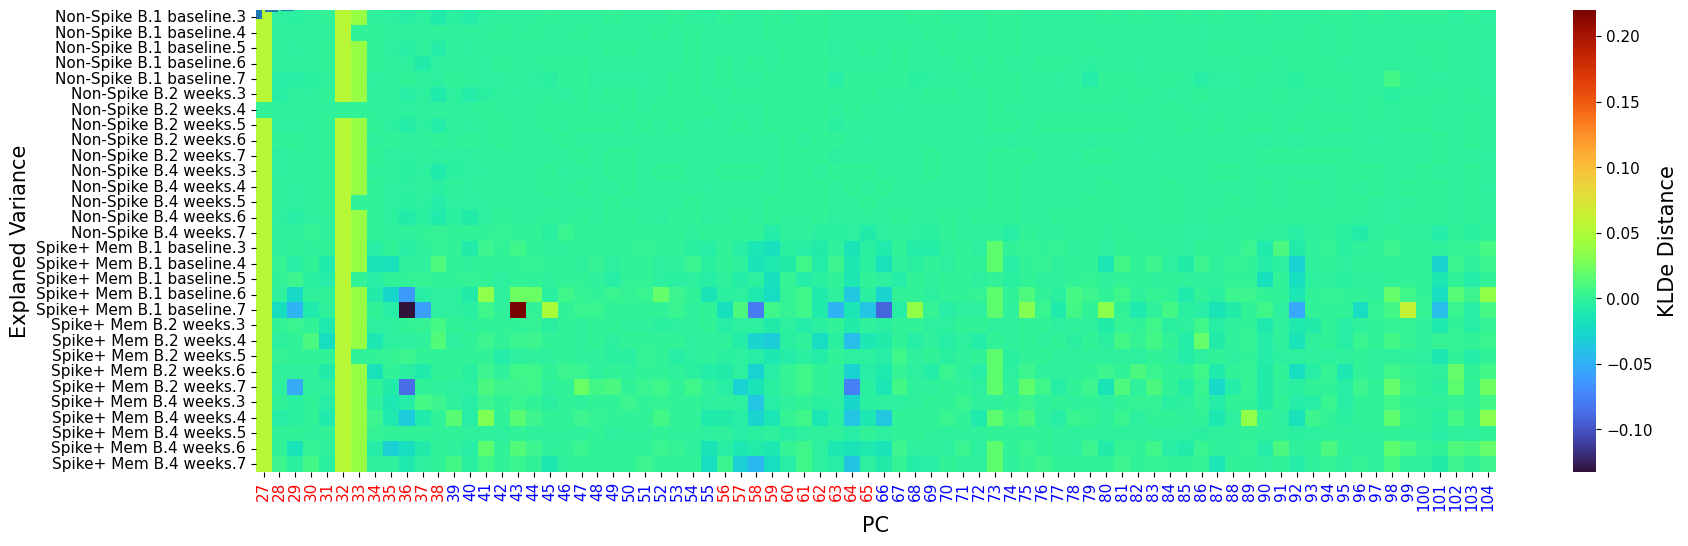

In [ ]:
perform_lpa = True
metric = ["substitution_survival", "trimers_usage"]
if perform_lpa:
    # Initiating the LPA algorithm object
    lpa_mutsub = lpa_analysis(metric=metric[0])

    #Plotting heatmap of the domain KLDe distances
    lpa_mutsub.heatmap()

    # Perform PCA and plot heatmap
    pca_mutsub = lpa_mutsub.pca()

    # Using scatter plot to visualize the PCA analysis
    lpa_mutsub.pca_scatter(n_pcs=2, label_index=0)